Authors:
- Iria Janeiro Pazos.
- Laura González Lemos.

In [1]:
import random
random.seed(1234)

In [2]:
# Download dataset
import tensorflow as tf
import tensorflow_datasets as tfds

raw_train_data, train_info = tfds.load('stl10', split='train', as_supervised=True, with_info=True) # tuple (image, label)
raw_test_data, test_info = tfds.load('stl10', split='test', as_supervised=True, with_info=True) # tuple (image, label)

2026-03-12 11:10:08.549789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 11:10:09.044687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773310215.492251    1418 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


2026-03-12 11:10:17.616547: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-03-12 11:10:17.631571: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,image,label
0,,1 (bird)
1,,0 (airplane)
2,,8 (ship)
3,,3 (cat)

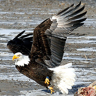
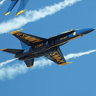
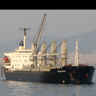
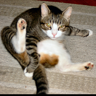

In [3]:
# Check train data
print('Number of classes:', train_info.features["label"].num_classes)
print('Classes names:', train_info.features["label"].names)
print()
print('Features shape:', train_info.features["image"].shape)
print('Features dtype:', train_info.features["image"].dtype)


tfds.as_dataframe(raw_train_data.take(4), train_info)


Number of classes: 10
Classes names: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Features shape: (96, 96, 3)
Features dtype: <dtype: 'uint8'>


2026-03-12 11:10:22.484085: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,image,label
0,,9 (truck)
1,,3 (cat)
2,,3 (cat)
3,,1 (bird)

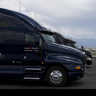
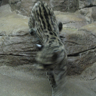
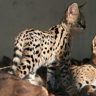
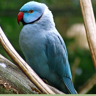

In [4]:
# Check test data
print('Number of classes:', test_info.features["label"].num_classes)
print('Classes names:', test_info.features["label"].names)
print()
print('Features shape:', test_info.features["image"].shape)
print('Features dtype:', test_info.features["image"].dtype)


tfds.as_dataframe(raw_test_data.take(4), test_info)

# Data Preprocessing

The first step in the project is to preprocess the data. We perform the following transformations:
- Image size normalization: We resize all images to a common size to ensure consistency in the input data.
- One hot encoding: We convert categorical labels into a binary format that can be used by machine learning algorithms.

In [5]:
# Preprocessing

def preprocess(image, label, train_info=train_info):
    # Rescale the image (normalize)
    image = tf.cast(image, tf.float32) / 255.0

    # One-hot encode the labels
    num_classes = train_info.features["label"].num_classes
    label = tf.one_hot(label, depth=num_classes)

    return image, label

prep_train_data = raw_train_data.map(preprocess)
test_data = raw_test_data.map(preprocess)

Secondly, we split the dataset into training and validation sets (80% training, 20% validation). A test split is not needed as the dataset already provides a seperate test set.

In [6]:
# Train-Validation split (80-20)
prep_train_data = prep_train_data.shuffle(1000, reshuffle_each_iteration=False) # Shuffle the dataset before splitting

num_samples = train_info.splits['train'].num_examples
train_size = int(0.8 * num_samples)

train_data = prep_train_data.take(train_size)
val_data = prep_train_data.skip(train_size)

In [7]:
BATCH_SIZE = 32

# 1. Batch the training data and use prefetch for speed
# We shuffle again here to ensure randomness within the batches
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 2. Batch the validation data
val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Batch the test data
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Helper Functions

In [8]:
import os

# Create a directory to save the models
save_dir = "CustomModels"

# Create the directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory '{save_dir}' created!")

In [9]:

def train_model(model, train_data, val_data, epochs=25, learning_rate=0.001, patience=5):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )

    callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1,
    )
]
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        callbacks=callbacks
    )
    return history

    

In [10]:
import matplotlib.pyplot as plt

def plot_history(history, model_name="Model"):
    """
    Plots the training and validation accuracy and loss.
    """
    # Extract metrics from the history object [cite: 230]
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{model_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.ylim(0, 1)  # Set y-axis limits for better visualization

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{model_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Baseline Model

- Low accuracy.
- Fast overfitting.

In [11]:
from tensorflow.keras import layers, models

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential([
        # 1. First Convolutional Block
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 2. Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 3. Third Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # 4. Flatten and Dense Layers for Classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [12]:
img_shape = train_info.features['image'].shape
num_classes = train_info.features['label'].num_classes

baseline = build_baseline_model(img_shape, num_classes)
baseline.summary()

/home/iriai/miniconda3/envs/deep_learning/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25


2026-03-11 12:13:10.857219: I external/local_xla/xla/service/service.cc:163] XLA service 0x71a56c003890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-11 12:13:10.857241: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-11 12:13:10.885545: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 12:13:11.088599: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-11 12:13:11.120702: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-11 12:13:12.

 16/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0856 - loss: 2.3320

I0000 00:00:1773227594.390799   52047 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.2603 - loss: 1.9255 - val_accuracy: 0.3690 - val_loss: 1.6707 - learning_rate: 0.0010
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4193 - loss: 1.5478 - val_accuracy: 0.3770 - val_loss: 1.6586 - learning_rate: 0.0010
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4900 - loss: 1.3644 - val_accuracy: 0.4570 - val_loss: 1.4524 - learning_rate: 0.0010
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5630 - loss: 1.2096 - val_accuracy: 0.5180 - val_loss: 1.3362 - learning_rate: 0.0010
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6298 - loss: 1.0457 - val_accuracy: 0.5430 - val_loss: 1.2620 - learning_rate: 0.0010
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6825 - loss: 0.8956 - val_accuracy: 0.5610 - val_loss: 1.3016 - learning_rate: 0.0010
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7312 - loss: 0.7483 - val_a

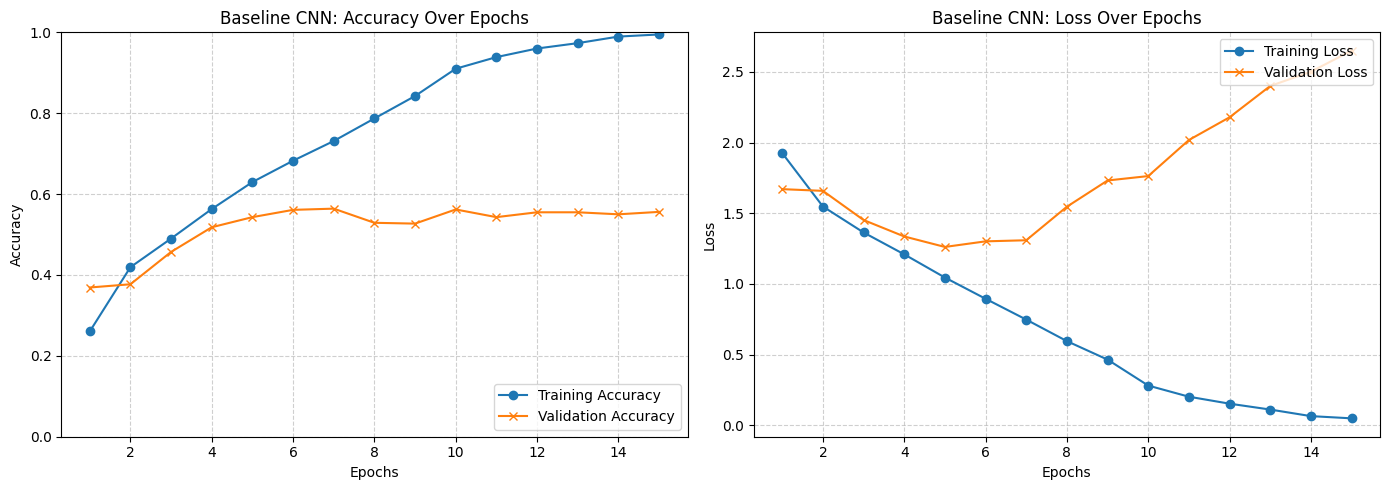

Baseline model saved to 'CustomModels/baseline_cnn.keras'


In [13]:
history = train_model(baseline, train_data, val_data)
plot_history(history, model_name="Baseline CNN")

baseline.save("CustomModels/baseline_cnn.keras")
print("Baseline model saved to 'CustomModels/baseline_cnn.keras'")

In [14]:
try:
    baseline = tf.keras.models.load_model("CustomModels/baseline_cnn.keras")
    print("Baseline model loaded successfully from 'CustomModels/baseline_cnn.keras'")
except Exception as e:
    print(f"Error loading baseline model: {e}")
    exit(1)

test_loss, test_accuracy = baseline.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Baseline model loaded successfully from 'CustomModels/baseline_cnn.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5351 - loss: 1.2951
Test Accuracy: 53.51%
Test Loss: 1.2951


# Custom CNN

Added Droupout

In [15]:
from tensorflow.keras import layers, models

def dropout_model(dropout_rate=0.5):
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

# Added Dropout

    model = models.Sequential([
    # 1. First Convolutional Block
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 2. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 3. Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 4. Flatten and Dense Layers for Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(num_classes, activation='softmax')
])
    
    return model



In [16]:
model = dropout_model()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,610 (4.86 MB)

 Trainable params: 1,273,610 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

-----Training with learning rate: 0.001, Dropout rate: 0.3-----
Epoch 1/50


2026-03-11 12:13:47.409273: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-11 12:13:48.132403: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_995', 520 bytes spill stores, 520 bytes spill loads



125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2512 - loss: 1.9808 - val_accuracy: 0.3870 - val_loss: 1.6515 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3730 - loss: 1.6339 - val_accuracy: 0.4410 - val_loss: 1.4431 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4525 - loss: 1.4471 - val_accuracy: 0.5010 - val_loss: 1.3588 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5077 - loss: 1.3086 - val_accuracy: 0.5010 - val_loss: 1.3249 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5667 - loss: 1.1697 - val_accuracy: 0.5400 - val_loss: 1.2776 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6150 - loss: 1.0543 - val_accuracy: 0.5260 - val_loss: 1.2974 - learning_rate: 0.0010
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6643 - loss: 0.9032 - val_

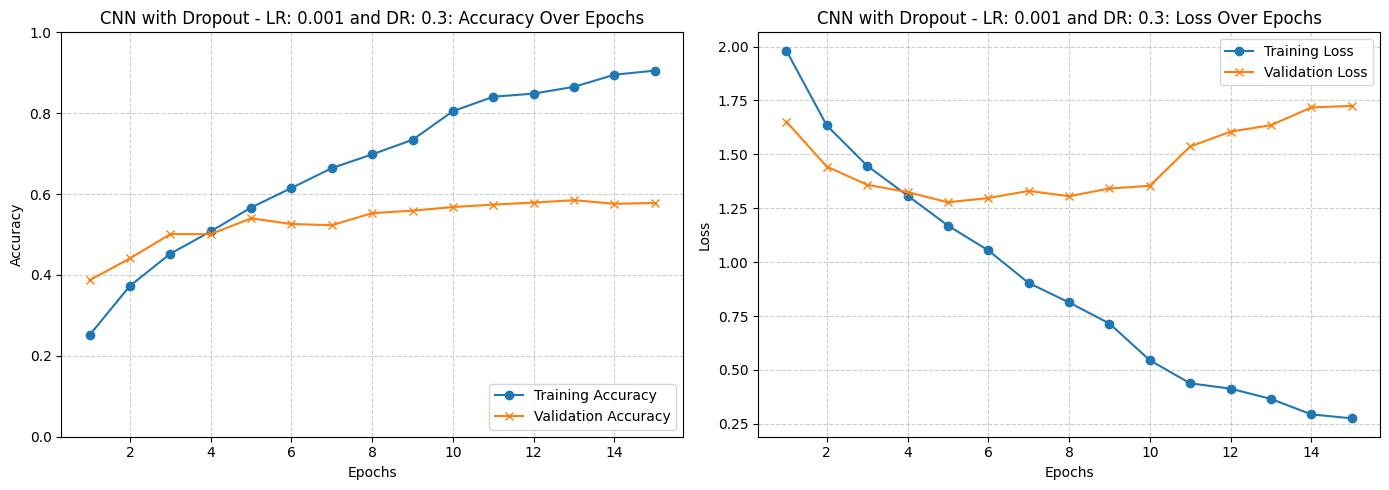

-----Training with learning rate: 0.001, Dropout rate: 0.5-----
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.2070 - loss: 2.1339 - val_accuracy: 0.3020 - val_loss: 1.9326 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2855 - loss: 1.8613 - val_accuracy: 0.3520 - val_loss: 1.6470 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3388 - loss: 1.7149 - val_accuracy: 0.4150 - val_loss: 1.5098 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4067 - loss: 1.5633 - val_accuracy: 0.4300 - val_loss: 1.4696 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4170 - loss: 1.5200 - val_accuracy: 0.4940 - val_loss: 1.4075 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4450 - loss: 1.4169 - val_accuracy: 0.5080 - val_loss: 1.3049 - learning_rate: 0.0010
Epoch 7/50
125/125

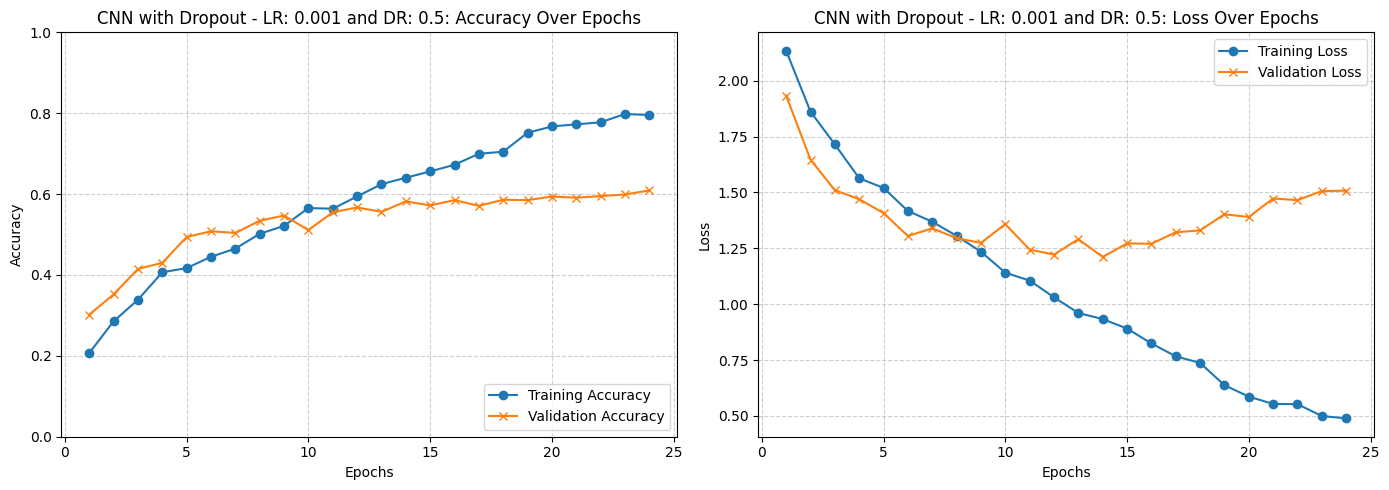

-----Training with learning rate: 0.0001, Dropout rate: 0.3-----
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2410 - loss: 2.0091 - val_accuracy: 0.3440 - val_loss: 1.7090 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3610 - loss: 1.6781 - val_accuracy: 0.4570 - val_loss: 1.4921 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4250 - loss: 1.5152 - val_accuracy: 0.4860 - val_loss: 1.4067 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4815 - loss: 1.3744 - val_accuracy: 0.5020 - val_loss: 1.3682 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5418 - loss: 1.2412 - val_accuracy: 0.5010 - val_loss: 1.3256 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5825 - loss: 1.1114 - val_accuracy: 0.5300 - val_loss: 1.3211 - learning_rate: 0.0010
Epoch 7/50
125/12

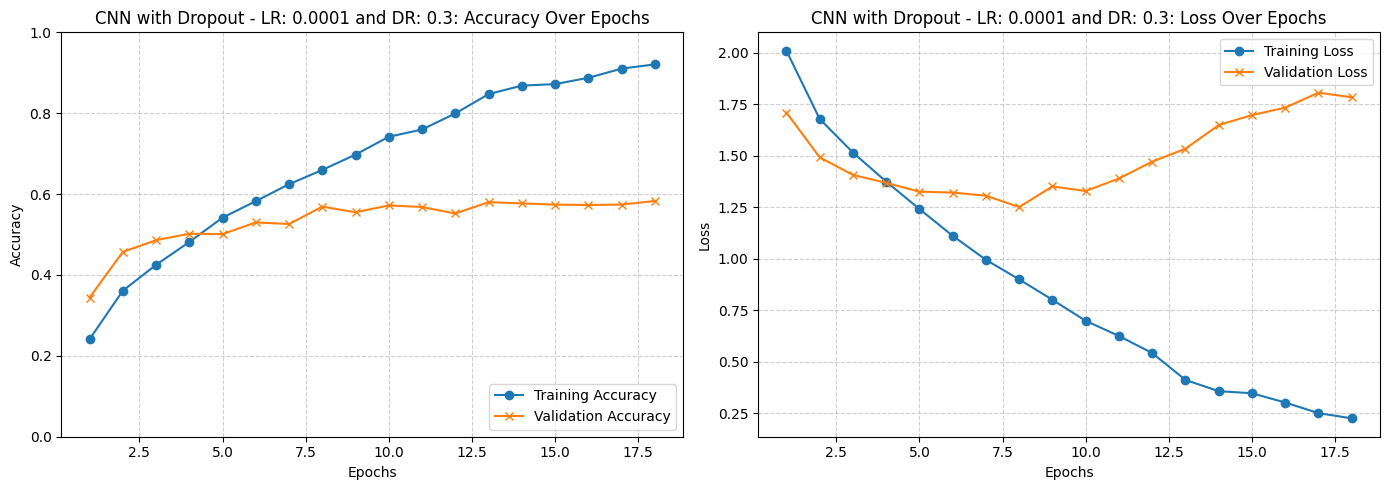

-----Training with learning rate: 0.0001, Dropout rate: 0.5-----
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2313 - loss: 2.0508 - val_accuracy: 0.3440 - val_loss: 1.7385 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3268 - loss: 1.7539 - val_accuracy: 0.3790 - val_loss: 1.6900 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3523 - loss: 1.6527 - val_accuracy: 0.4200 - val_loss: 1.4719 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3938 - loss: 1.5798 - val_accuracy: 0.4520 - val_loss: 1.4479 - learning_rate: 0.0010
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4378 - loss: 1.4765 - val_accuracy: 0.4860 - val_loss: 1.3808 - learning_rate: 0.0010
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4495 - loss: 1.4048 - val_accuracy: 0.4640 - val_loss: 1.4050 - learning_rate: 0.0010
Epoch 7/50
125/12

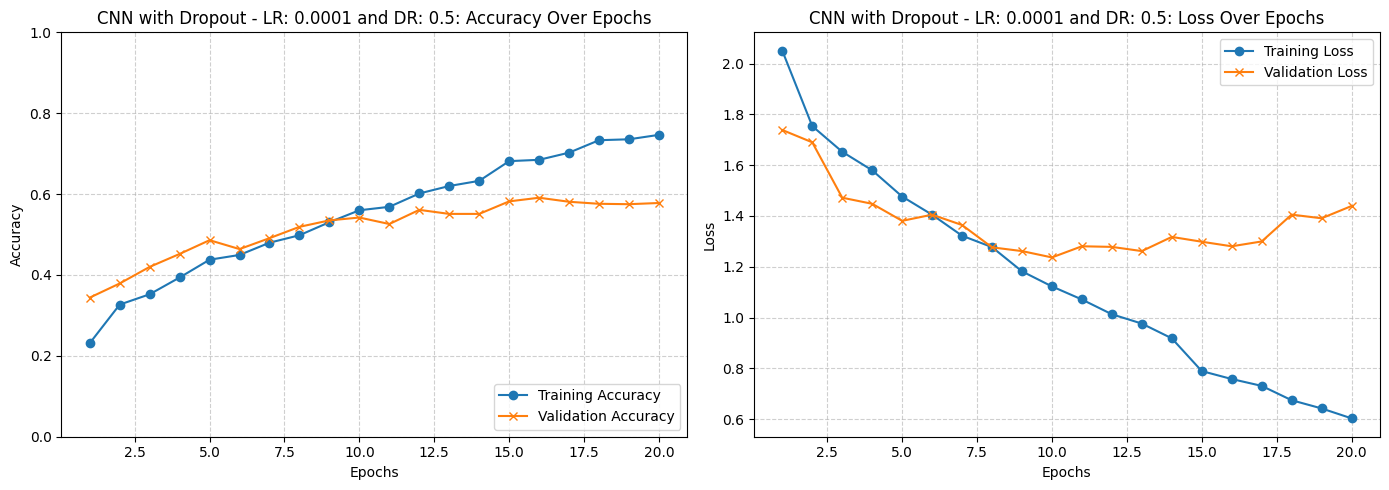

Best Hyperparameters: Learning Rate = 0.001, Dropout Rate = 0.5
Best hyperparameters saved to 'CustomModels/dropout_cnn_hyperparams.json'


In [17]:
import json
import os

learning_rates = [0.001, 0.0001]
dropout_rates = [0.3, 0.5]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    for dr in dropout_rates:
        print(f"-----Training with learning rate: {lr}, Dropout rate: {dr}-----")
        model = dropout_model(dropout_rate=dr)
        history = train_model(model, train_data, val_data, epochs=50)

        # Find the epoch early stopping restored weights to (lowest val_loss)
        best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
        best_epoch_val_acc = history.history['val_accuracy'][best_epoch]

        # Save the best model based on validation accuracy
        if best_epoch_val_acc > best_val_acc:
            best_val_acc = best_epoch_val_acc
            model.save(f"CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras")
            best_hyperparams = [lr, dr]
            print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")


        plot_history(history, model_name=f"CNN with Dropout - LR: {lr} and DR: {dr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}, Dropout Rate = {best_hyperparams[1]}")
# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0],
    'dropout_rate': best_hyperparams[1]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "dropout_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/dropout_cnn_hyperparams.json'")

In [18]:
import json
json_path = "CustomModels/dropout_cnn_hyperparams.json"
try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']
    dr = hyperparams['dropout_rate']
    model = tf.keras.models.load_model(f"CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras")
    print(f"Best model loaded successfully from 'CustomModels/dropout_cnn_lr_{lr}_dr_{dr}.keras'")

except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)
    
test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/dropout_cnn_lr_0.001_dr_0.5.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5779 - loss: 1.2419
Test Accuracy: 57.79%
Test Loss: 1.2419


Data Augmentation

In [19]:
from tensorflow.keras import layers, models

def augmen_model(dropout_rate=0.5, rotation_factor = 0.1):
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

    model = models.Sequential([
    # 1. First Convolutional Block
    layers.InputLayer(input_shape=input_shape),
    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(rotation_factor),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 2. Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 3. Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    # 4. Flatten and Dense Layers for Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])
    
    return model

model = augmen_model()

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,610 (4.86 MB)

 Trainable params: 1,273,610 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

-----Training with learning rate: 0.001, Dropout rate: 0.5, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.1618 - loss: 2.2014 - val_accuracy: 0.2850 - val_loss: 2.0439 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2380 - loss: 2.0161 - val_accuracy: 0.2920 - val_loss: 1.8399 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2783 - loss: 1.8447 - val_accuracy: 0.3280 - val_loss: 1.6593 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2898 - loss: 1.7880 - val_accuracy: 0.3480 - val_loss: 1.6393 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3113 - loss: 1.7301 - val_accuracy: 0.4000 - val_loss: 1.5594 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3300 - loss: 1.6933 - val_accuracy: 0.3970 - val_loss: 1.5117 - learning_rat

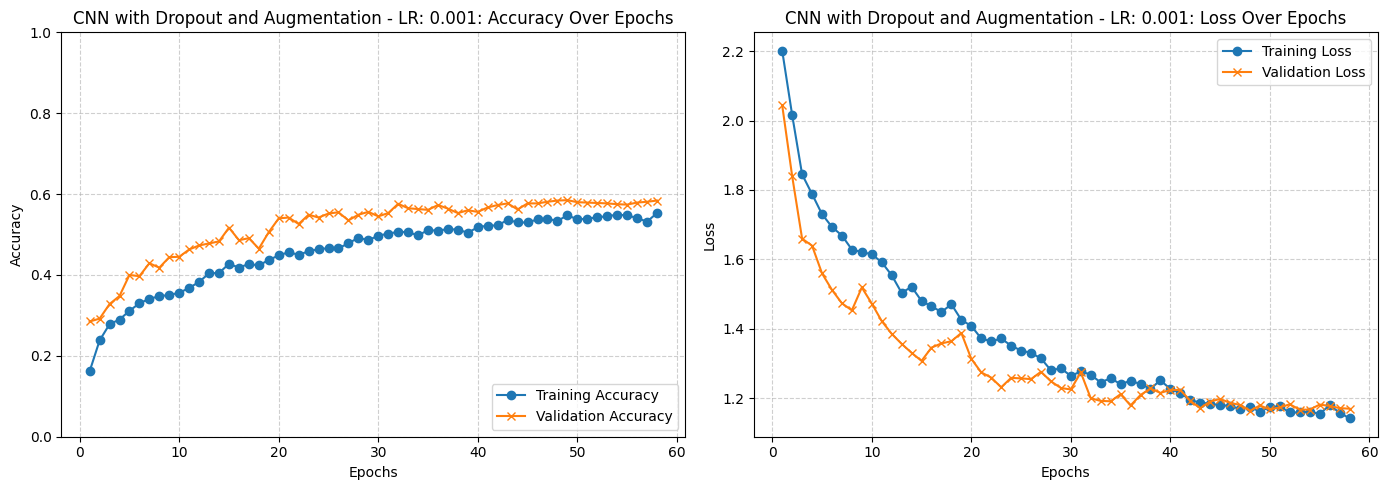

-----Training with learning rate: 0.001, Dropout rate: 0.5, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1835 - loss: 2.1165 - val_accuracy: 0.2740 - val_loss: 1.9353 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2453 - loss: 1.9536 - val_accuracy: 0.3070 - val_loss: 1.8823 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2797 - loss: 1.8713 - val_accuracy: 0.3500 - val_loss: 1.7705 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2960 - loss: 1.8226 - val_accuracy: 0.3390 - val_loss: 1.7418 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3047 - loss: 1.7866 - val_accuracy: 0.3410 - val_loss: 1.7502 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3268 - loss: 1.7490 - val_accuracy: 0.3770 - val_loss: 1.6476 - learning_rat

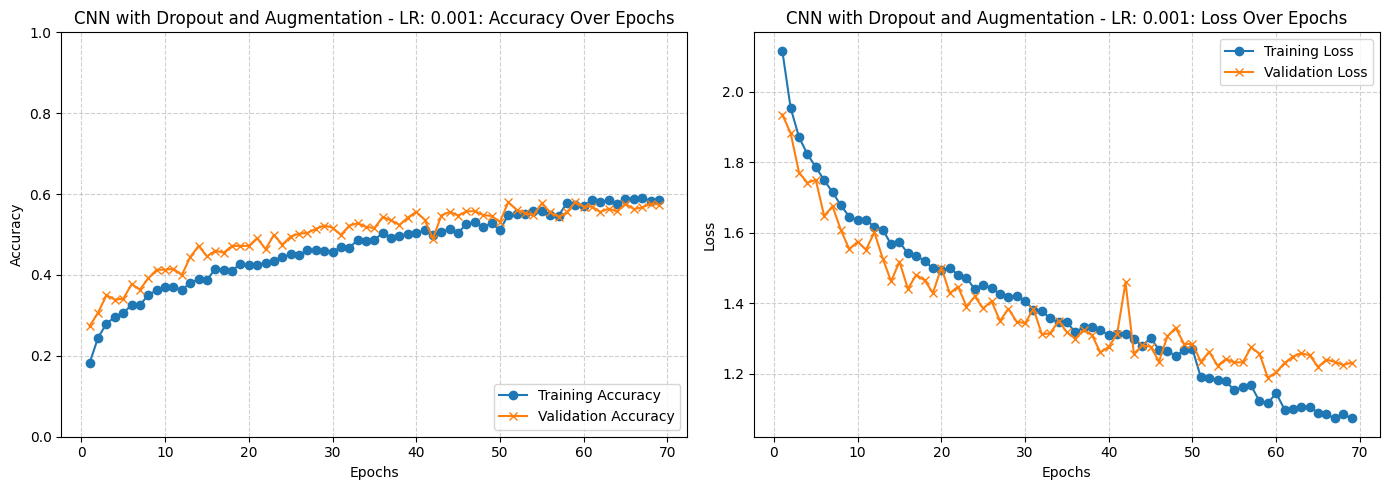

-----Training with learning rate: 0.001, Dropout rate: 0.7, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.1710 - loss: 2.1955 - val_accuracy: 0.2520 - val_loss: 2.0000 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2475 - loss: 1.9831 - val_accuracy: 0.3350 - val_loss: 1.7518 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2887 - loss: 1.8320 - val_accuracy: 0.3650 - val_loss: 1.6560 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3083 - loss: 1.7933 - val_accuracy: 0.3690 - val_loss: 1.6403 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3220 - loss: 1.7409 - val_accuracy: 0.3960 - val_loss: 1.5830 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3190 - loss: 1.7143 - val_accuracy: 0.4160 - val_loss: 1.5138 - learning_rat

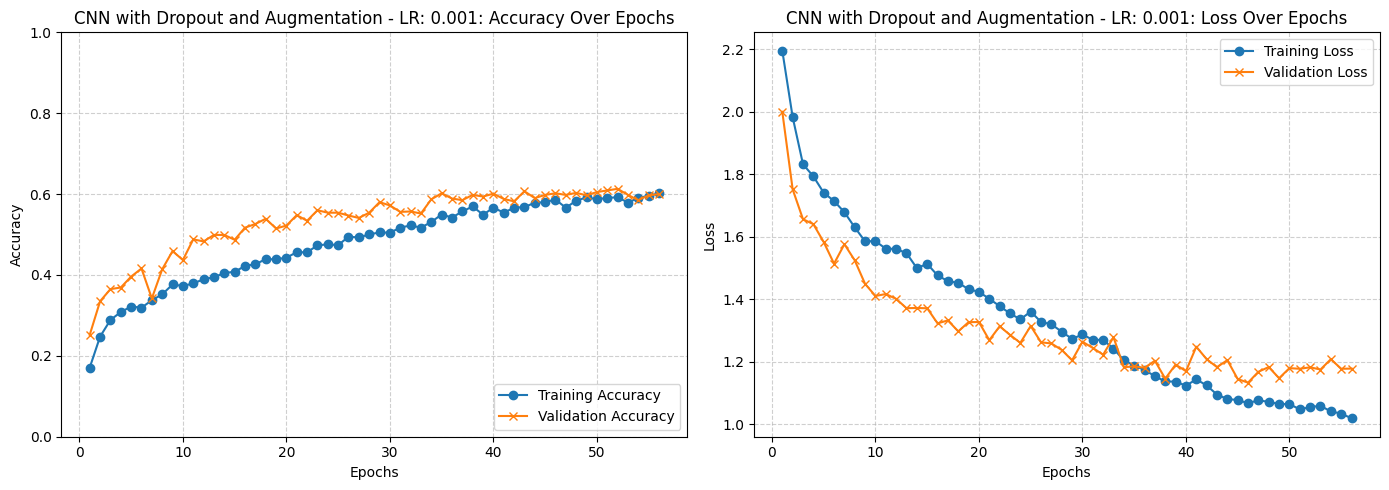

-----Training with learning rate: 0.001, Dropout rate: 0.7, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1785 - loss: 2.1558 - val_accuracy: 0.2650 - val_loss: 1.9793 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2438 - loss: 1.9878 - val_accuracy: 0.3030 - val_loss: 1.8794 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2688 - loss: 1.9097 - val_accuracy: 0.3240 - val_loss: 1.8080 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2682 - loss: 1.8682 - val_accuracy: 0.3280 - val_loss: 1.7357 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2885 - loss: 1.7911 - val_accuracy: 0.3220 - val_loss: 1.7502 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3090 - loss: 1.7814 - val_accuracy: 0.3420 - val_loss: 1.7081 - learning_rat

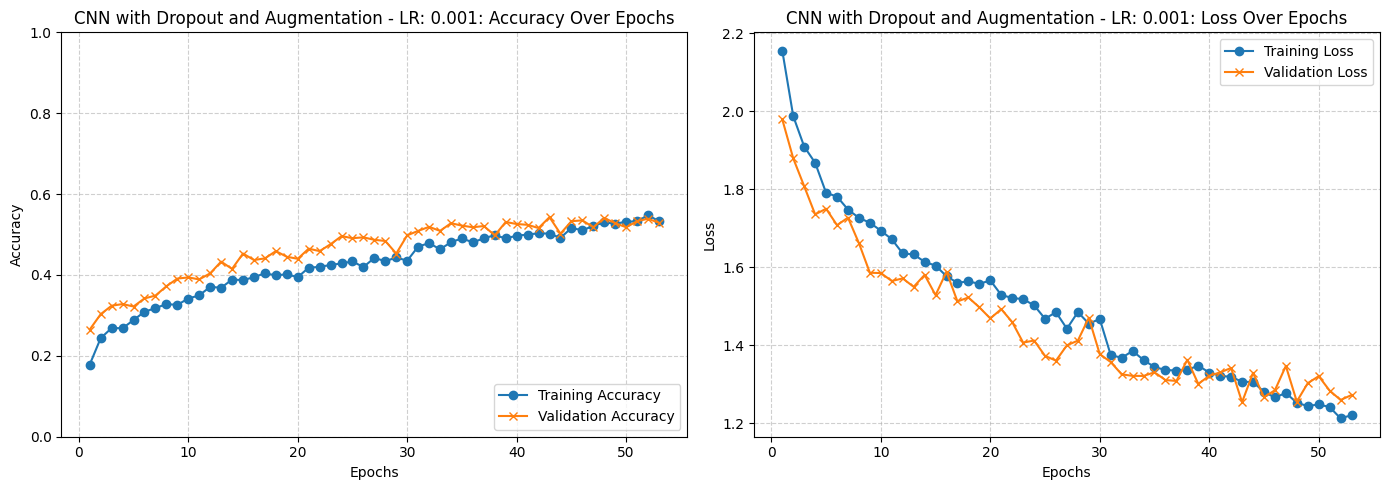

-----Training with learning rate: 0.0005, Dropout rate: 0.5, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1950 - loss: 2.1303 - val_accuracy: 0.3090 - val_loss: 1.8331 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2615 - loss: 1.9292 - val_accuracy: 0.3640 - val_loss: 1.7439 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3005 - loss: 1.8376 - val_accuracy: 0.3910 - val_loss: 1.6577 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3147 - loss: 1.7711 - val_accuracy: 0.4070 - val_loss: 1.5533 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3520 - loss: 1.6999 - val_accuracy: 0.4200 - val_loss: 1.5239 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3647 - loss: 1.6648 - val_accuracy: 0.4570 - val_loss: 

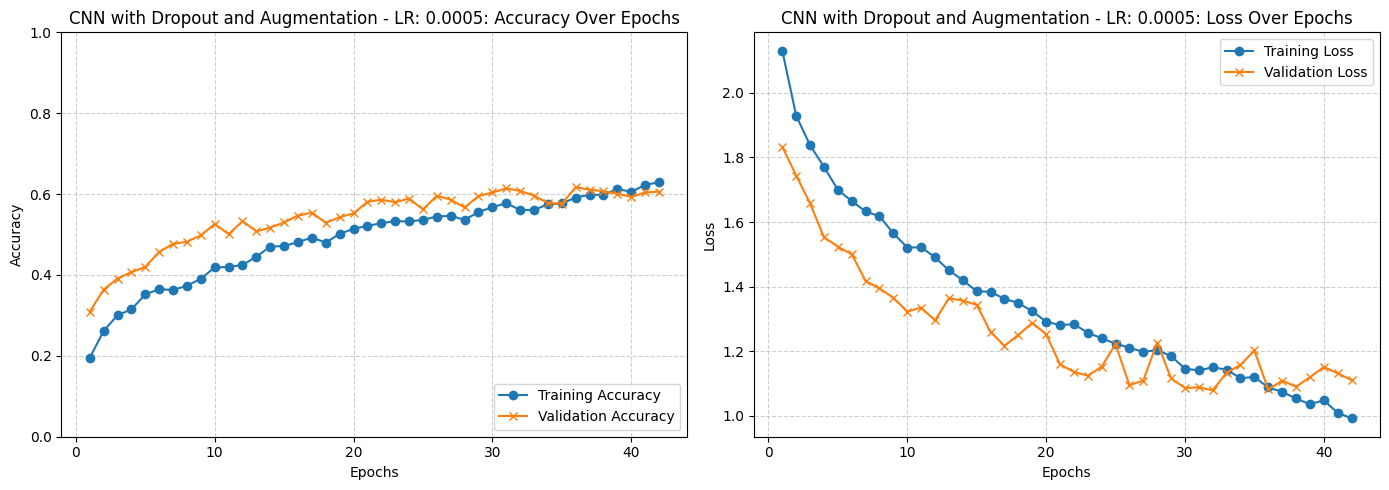

-----Training with learning rate: 0.0005, Dropout rate: 0.5, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1733 - loss: 2.1803 - val_accuracy: 0.2350 - val_loss: 2.0423 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2290 - loss: 2.0218 - val_accuracy: 0.2850 - val_loss: 1.9220 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2560 - loss: 1.9303 - val_accuracy: 0.3570 - val_loss: 1.7623 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2800 - loss: 1.8528 - val_accuracy: 0.3400 - val_loss: 1.8050 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2990 - loss: 1.8096 - val_accuracy: 0.3600 - val_loss: 1.7230 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3013 - loss: 1.7922 - val_accuracy: 0.3720 - val_loss: 

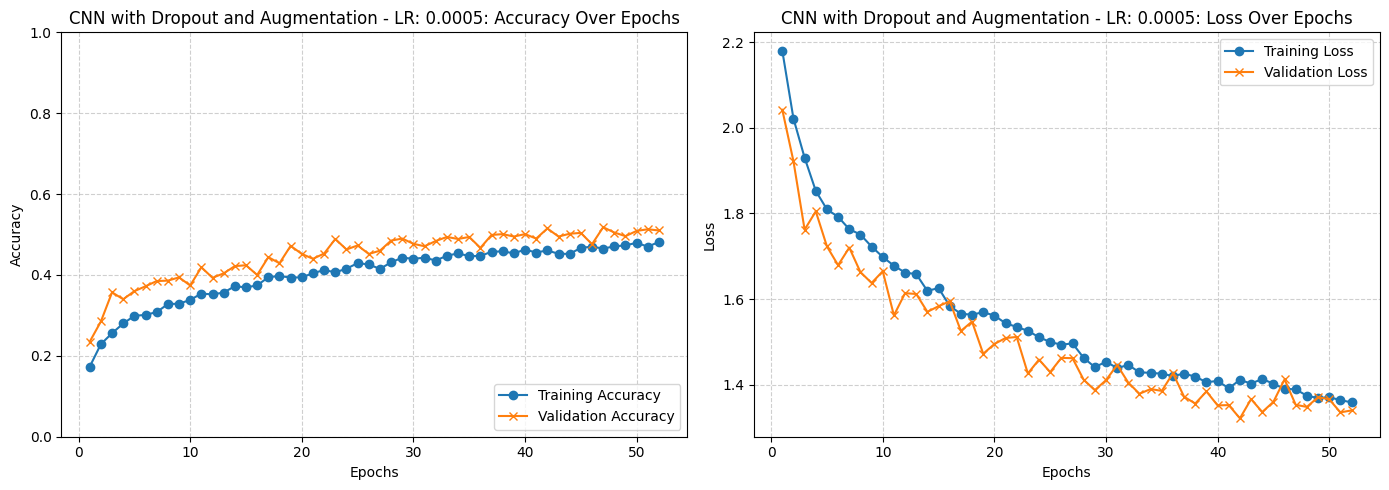

-----Training with learning rate: 0.0005, Dropout rate: 0.7, Rotation factor: 0.1-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1995 - loss: 2.1325 - val_accuracy: 0.3070 - val_loss: 1.8724 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2837 - loss: 1.9072 - val_accuracy: 0.3800 - val_loss: 1.6643 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3210 - loss: 1.8124 - val_accuracy: 0.3890 - val_loss: 1.6550 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3540 - loss: 1.7404 - val_accuracy: 0.4060 - val_loss: 1.5857 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3607 - loss: 1.6828 - val_accuracy: 0.4210 - val_loss: 1.5551 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3742 - loss: 1.6355 - val_accuracy: 0.4630 - val_loss: 

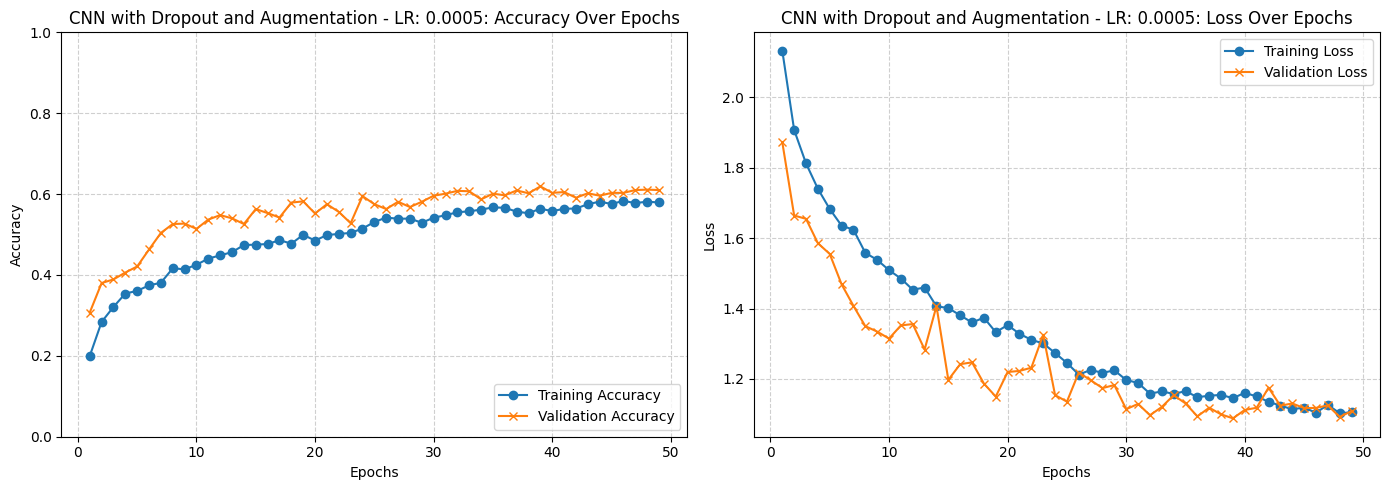

-----Training with learning rate: 0.0005, Dropout rate: 0.7, Rotation factor: 0.3-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1775 - loss: 2.1507 - val_accuracy: 0.2850 - val_loss: 1.9330 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2567 - loss: 1.9729 - val_accuracy: 0.2840 - val_loss: 1.9796 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2688 - loss: 1.9247 - val_accuracy: 0.3350 - val_loss: 1.8075 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2948 - loss: 1.8454 - val_accuracy: 0.3560 - val_loss: 1.7127 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.3075 - loss: 1.8314 - val_accuracy: 0.3720 - val_loss: 1.6831 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3160 - loss: 1.7797 - val_accuracy: 0.3770 - val_loss: 

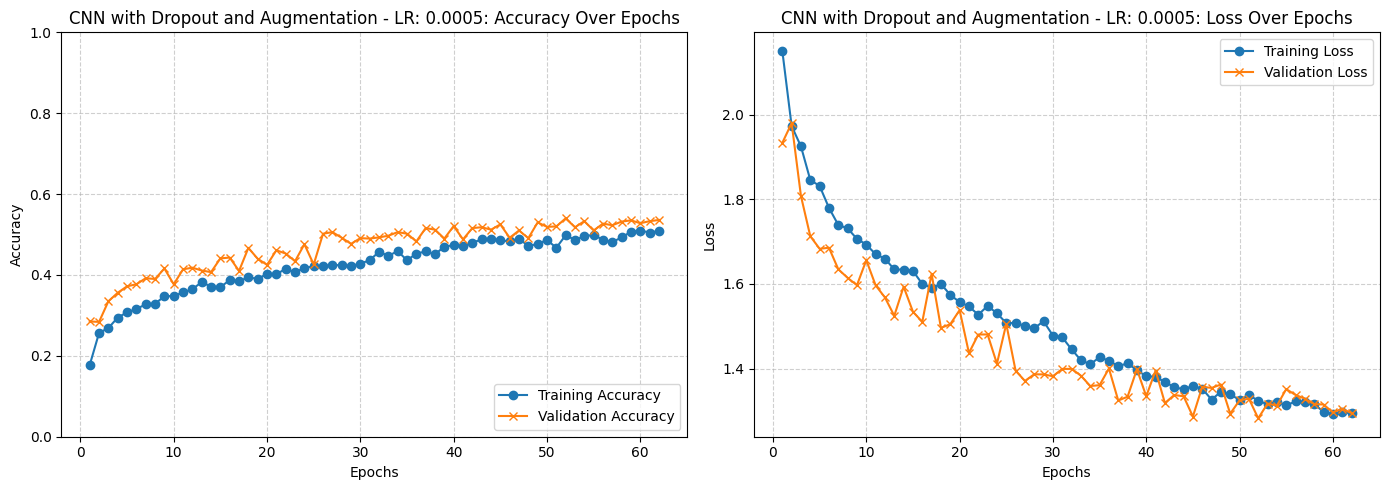

Best Hyperparameters: Learning Rate = 0.0005, Dropout Rate = 0.7, Rotation Factor = 0.1
Best hyperparameters saved to 'CustomModels/augmen_cnn_hyperparams.json'


In [20]:
import json
import os

learning_rates = [0.001, 0.0005]
dropout_rates = [0.5, 0.7]
rotation_factors = [0.1, 0.3]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    for dr in dropout_rates:
        for rf in rotation_factors:
            print(f"-----Training with learning rate: {lr}, Dropout rate: {dr}, Rotation factor: {rf}-----")
            model = augmen_model(dropout_rate=dr, rotation_factor=rf)
            history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
            
            # Find the epoch early stopping restored weights to (lowest val_loss)
            best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
            best_epoch_val_acc = history.history['val_accuracy'][best_epoch]
            # Save the best model based on validation accuracy
            if best_epoch_val_acc > best_val_acc:
                best_val_acc = best_epoch_val_acc
                model.save(f"CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras")
                best_hyperparams = [lr, dr, rf]
                print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
    
            plot_history(history, model_name=f"CNN with Dropout and Augmentation - LR: {lr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}, Dropout Rate = {best_hyperparams[1]}, Rotation Factor = {best_hyperparams[2]}")

# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0],
    'dropout_rate': best_hyperparams[1],
    'rotation_factor': best_hyperparams[2]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "augmen_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/augmen_cnn_hyperparams.json'")

In [21]:
import json
json_path = "CustomModels/augmen_cnn_hyperparams.json"

try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']
    dr = hyperparams['dropout_rate']
    rf = hyperparams['rotation_factor']

    model = tf.keras.models.load_model(f"CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras")
    print(f"Best model loaded successfully from 'CustomModels/augmen_cnn_lr_{lr}_dr_{dr}_rf_{rf}.keras'")
except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)

test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/augmen_cnn_lr_0.0005_dr_0.7_rf_0.1.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6149 - loss: 1.0962
Test Accuracy: 61.49%
Test Loss: 1.0962


# Refined CNN

In [22]:
from tensorflow.keras import layers, models

def conv_block(x, filters, dropout_rate=0.3):
    """Double conv + BN + ReLU + MaxPool + Dropout."""
    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x

def refined_model():
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes

    inputs = tf.keras.Input(shape=input_shape)

    data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    ], name="augmentation")

    x = data_augmentation(inputs)

    x = conv_block(x, filters=32,  dropout_rate=0.2) 
    x = conv_block(x, filters=64,  dropout_rate=0.2) 
    x = conv_block(x, filters=128, dropout_rate=0.3) 
    x = conv_block(x, filters=256, dropout_rate=0.3) 

    # Extra single conv at the same scale to deepen without another pool
    x = tf.keras.layers.Conv2D(256, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Classification head 
    x = tf.keras.layers.GlobalAveragePooling2D()(x) 
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name="Improved_Custom_CNN")

# Initialize the new model

deep_model = refined_model()

deep_model.summary()

Model: "Improved_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,035,754 (7.77 MB)

 Trainable params: 2,031,786 (7.75 MB)

 Non-trainable params: 3,968 (15.50 KB)

-----Training with learning rate: 0.001-----
Epoch 1/100


E0000 00:00:1773229409.559379   51828 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Improved_Custom_CNN_1/dropout_20_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.2093 - loss: 2.7430 - val_accuracy: 0.0900 - val_loss: 2.7894 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.2442 - loss: 2.3104 - val_accuracy: 0.1050 - val_loss: 4.6702 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.2758 - loss: 2.0699 - val_accuracy: 0.1140 - val_loss: 3.9035 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.2985 - loss: 1.9302 - val_accuracy: 0.1960 - val_loss: 2.6950 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.3413 - loss: 1.7849 - val_accuracy: 0.2430 - val_loss: 2.4400 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.3823 - loss: 1.6789 - val_accuracy: 0.2820 - val_loss: 1.7871 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.4210 - loss: 

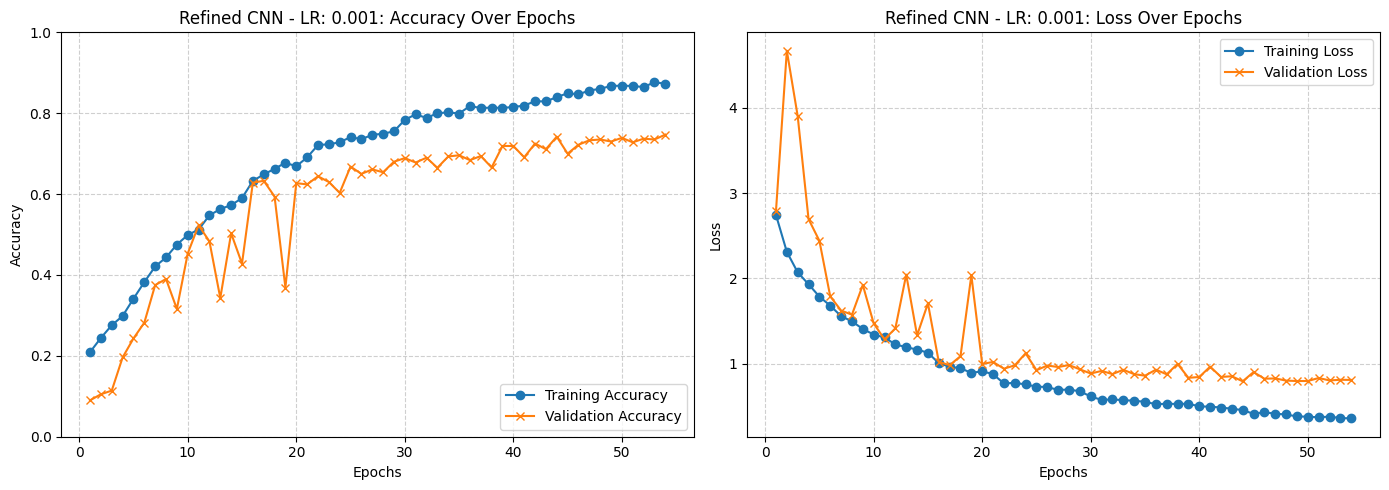

-----Training with learning rate: 0.0005-----
Epoch 1/100


E0000 00:00:1773230078.356843   51828 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Improved_Custom_CNN_1/dropout_26_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.2095 - loss: 2.7390 - val_accuracy: 0.1150 - val_loss: 2.4827 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.2688 - loss: 2.2572 - val_accuracy: 0.1160 - val_loss: 2.8209 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.2858 - loss: 2.1197 - val_accuracy: 0.1610 - val_loss: 2.9134 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.3243 - loss: 1.9559 - val_accuracy: 0.2870 - val_loss: 1.9649 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.3467 - loss: 1.8505 - val_accuracy: 0.3350 - val_loss: 1.7449 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.3873 - loss: 1.7106 - val_accuracy: 0.2400 - val_loss: 2.3488 - learning_rate: 5.0000e-04
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step -

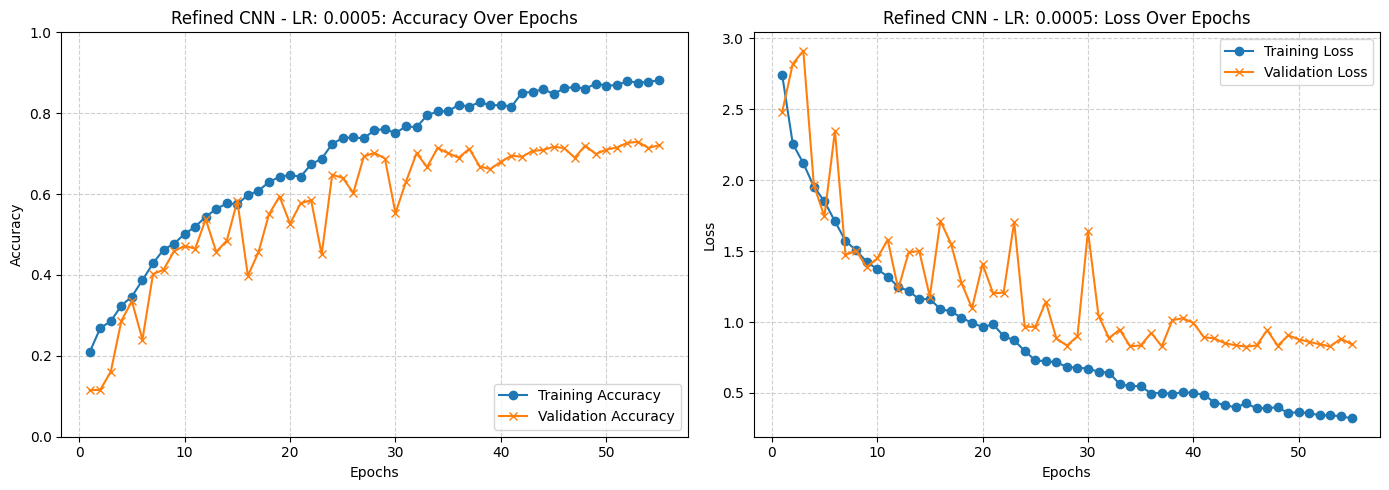

-----Training with learning rate: 0.0001-----
Epoch 1/100


E0000 00:00:1773230766.958450   51828 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Improved_Custom_CNN_1/dropout_32_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.1700 - loss: 3.0227 - val_accuracy: 0.1020 - val_loss: 2.3684 - learning_rate: 1.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.2208 - loss: 2.6278 - val_accuracy: 0.1550 - val_loss: 2.5260 - learning_rate: 1.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.2453 - loss: 2.3855 - val_accuracy: 0.1160 - val_loss: 2.9664 - learning_rate: 1.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.2797 - loss: 2.2533 - val_accuracy: 0.1320 - val_loss: 3.3152 - learning_rate: 1.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3014 - loss: 2.1606
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.2970 - loss: 2.1605 - val_accuracy: 0.1260 - val_loss: 3.3052 - learning_rate: 1.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accurac

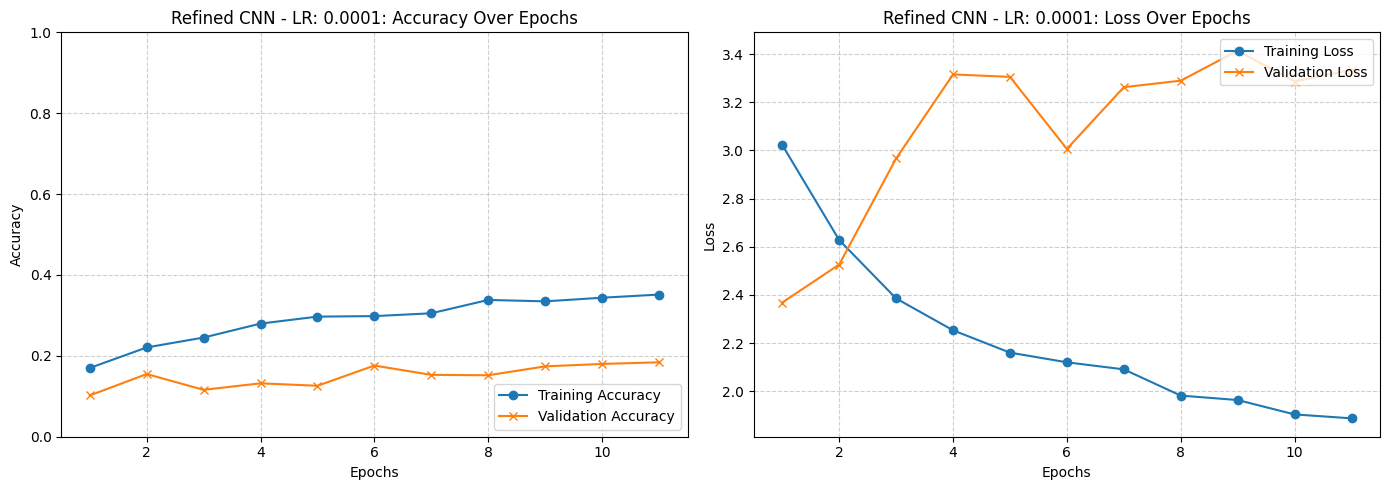

Best Hyperparameters: Learning Rate = 0.001
Best hyperparameters saved to 'CustomModels/refined_cnn_hyperparams.json'


In [23]:
import json
import os

learning_rates = [0.001, 0.0005, 0.0001]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    print(f"-----Training with learning rate: {lr}-----")
    model = refined_model()
    history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
            
    # Find the epoch early stopping restored weights to (lowest val_loss)
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
    best_epoch_val_acc = history.history['val_accuracy'][best_epoch]
    
    # Save the best model based on validation accuracy
    if best_epoch_val_acc > best_val_acc:
        best_val_acc = best_epoch_val_acc
        model.save(f"CustomModels/refined_cnn_lr_{lr}.keras")
        best_hyperparams = [lr]
        print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
    
    plot_history(history, model_name=f"Refined CNN - LR: {lr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}")

# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "refined_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/refined_cnn_hyperparams.json'")

In [24]:
import json
json_path = "CustomModels/refined_cnn_hyperparams.json"

try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']

    model = tf.keras.models.load_model(f"CustomModels/refined_cnn_lr_{lr}.keras")
    print(f"Best model loaded successfully from 'CustomModels/refined_cnn_lr_{lr}.keras'")
except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)

test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/refined_cnn_lr_0.001.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7414 - loss: 0.7798
Test Accuracy: 74.14%
Test Loss: 0.7798


# RestNet

In [13]:
from tensorflow.keras import layers, models, regularizers

def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Projection shortcut — now also regularised
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same',
                                 use_bias=False,
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def resNet_model():
    input_shape = train_info.features['image'].shape
    num_classes = train_info.features['label'].num_classes
    inputs = layers.Input(shape=input_shape)

    # Augmentation — RandomRotation removed (GPU layout bug)
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.1)(x)

    # Stronger stem: 64 filters instead of 32
    x = layers.Conv2D(64, (3, 3), padding='same',
                      use_bias=False,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Stage 1 — 64 filters, 96×96
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    # Stage 2 — 128 filters, downsample to 48×48
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # Stage 3 — 256 filters, downsample to 24×24
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Stage 4 — 512 filters, downsample to 12×12
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)

    # BN + ReLU before pooling
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Classification head — dropout only here, not inside the residual stack
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)
    
resNet_model().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 96, 96, 3) │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 96, 96, 3) │          0 │ random_flip_1[0]… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_1   │ (None, 96, 96, 3) │          0 │ random_zoom_1[0]… │
│ (RandomContrast)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 96, 96,    │      1,728 │ random_contrast_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 96, 96,    │          0 │ add_8[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 96, 96,    │     36,864 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 96, 96,    │          0 │ batch_normalizat

 Total params: 11,315,402 (43.16 MB)

 Trainable params: 11,304,266 (43.12 MB)

 Non-trainable params: 11,136 (43.50 KB)

-----Training with learning rate: 0.001-----
Epoch 1/100


2026-03-12 11:14:34.668335: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 341ms/step - accuracy: 0.2298 - loss: 2.8548 - val_accuracy: 0.1280 - val_loss: 3.3524 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - accuracy: 0.2525 - loss: 2.6045 - val_accuracy: 0.1480 - val_loss: 3.3323 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 330ms/step - accuracy: 0.2912 - loss: 2.4065 - val_accuracy: 0.1250 - val_loss: 3.3541 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 343ms/step - accuracy: 0.3133 - loss: 2.2807 - val_accuracy: 0.1840 - val_loss: 3.0979 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 361ms/step - accuracy: 0.3455 - loss: 2.1769 - val_accuracy: 0.2330 - val_loss: 2.7390 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 336ms/step - accuracy: 0.3762 - loss: 2.0678 - val_accuracy: 0.2720 - val_loss: 2.4741 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 367ms/step - accuracy: 0.3943 -

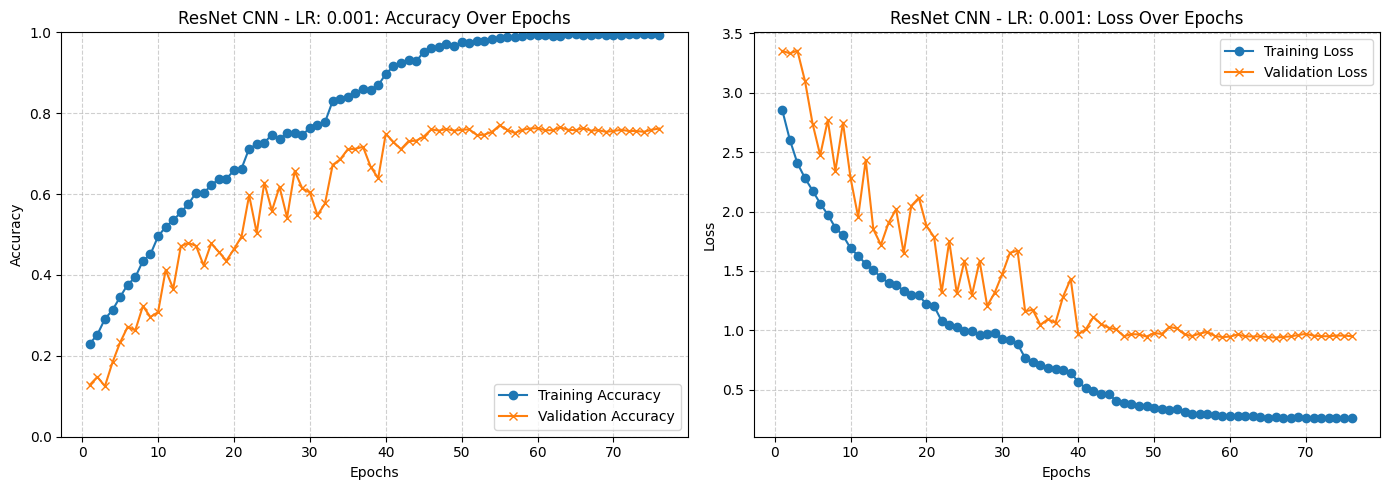

-----Training with learning rate: 0.0005-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 359ms/step - accuracy: 0.2460 - loss: 2.8524 - val_accuracy: 0.1440 - val_loss: 2.8690 - learning_rate: 5.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 360ms/step - accuracy: 0.2803 - loss: 2.5695 - val_accuracy: 0.1160 - val_loss: 3.5164 - learning_rate: 5.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 363ms/step - accuracy: 0.3105 - loss: 2.4357 - val_accuracy: 0.2010 - val_loss: 2.6223 - learning_rate: 5.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 364ms/step - accuracy: 0.3268 - loss: 2.2938 - val_accuracy: 0.2880 - val_loss: 2.2585 - learning_rate: 5.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 362ms/step - accuracy: 0.3823 - loss: 2.1382 - val_accuracy: 0.1910 - val_loss: 3.2737 - learning_rate: 5.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 362ms/step - accuracy: 0.4210 - loss: 2.0553 - val_accuracy: 0.3760 - val_loss: 2.1071 - learning_rate: 5.000

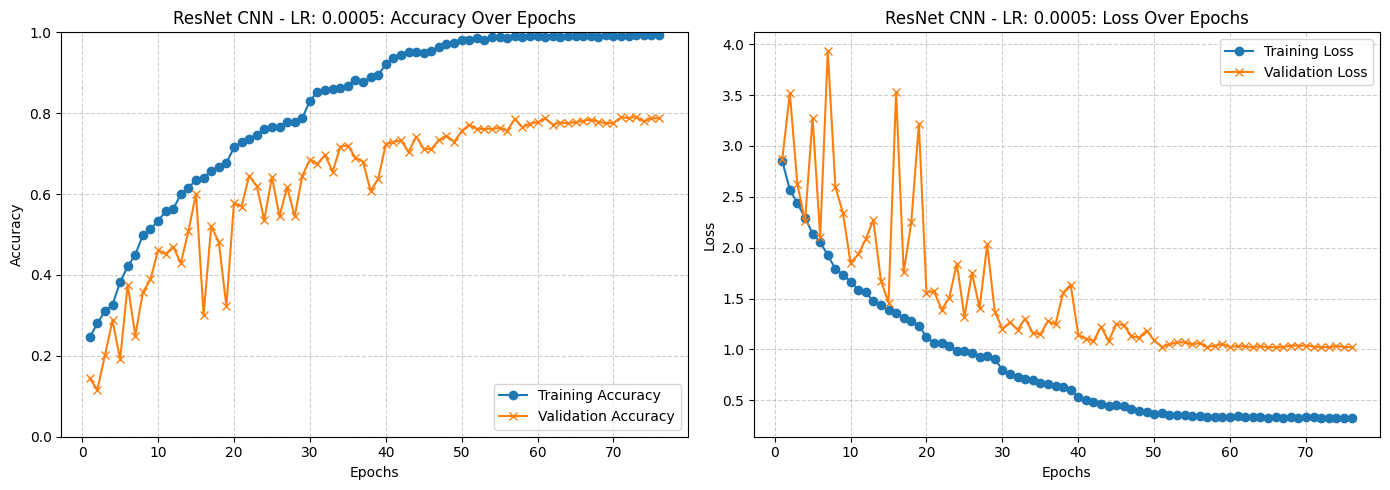

-----Training with learning rate: 0.0001-----
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 54s 368ms/step - accuracy: 0.2587 - loss: 2.7719 - val_accuracy: 0.1010 - val_loss: 3.6074 - learning_rate: 1.0000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 366ms/step - accuracy: 0.3145 - loss: 2.4599 - val_accuracy: 0.0920 - val_loss: 4.1128 - learning_rate: 1.0000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 361ms/step - accuracy: 0.3607 - loss: 2.3153 - val_accuracy: 0.1530 - val_loss: 3.4730 - learning_rate: 1.0000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 365ms/step - accuracy: 0.3787 - loss: 2.2517 - val_accuracy: 0.3010 - val_loss: 2.4398 - learning_rate: 1.0000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 365ms/step - accuracy: 0.4092 - loss: 2.1309 - val_accuracy: 0.3760 - val_loss: 2.1633 - learning_rate: 1.0000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 365ms/step - accuracy: 0.4455 - loss: 2.0710 - val_accuracy: 0.4340 - val_loss: 1.9950 - learning_rate: 1.000

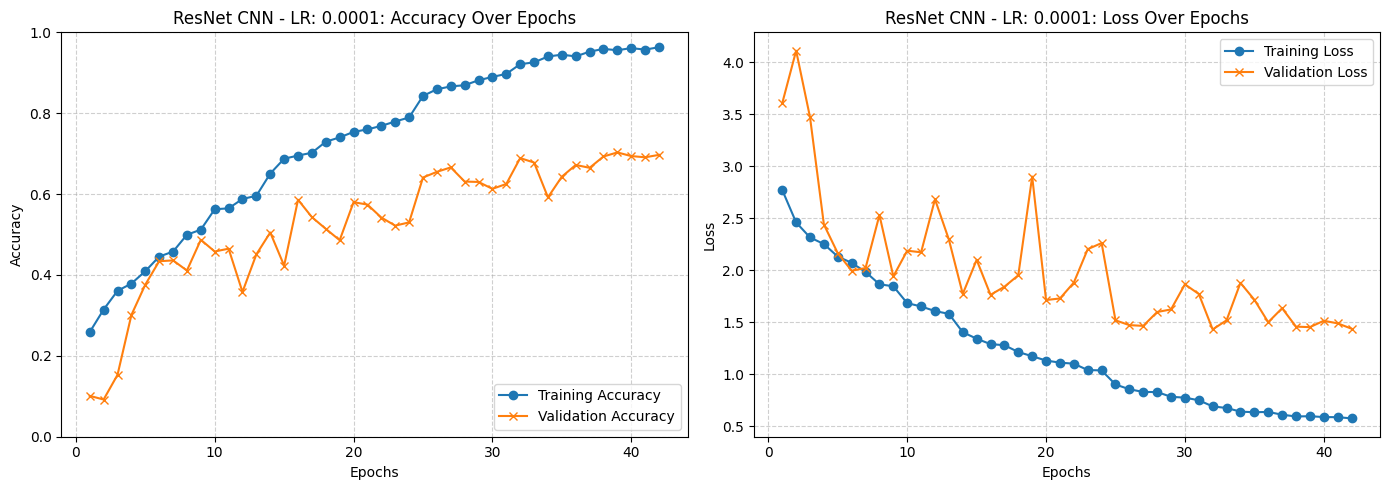

Best Hyperparameters: Learning Rate = 0.0005
Best hyperparameters saved to 'CustomModels/ResNet_cnn_hyperparams.json'


In [14]:
import json
import os

learning_rates = [0.001, 0.0005, 0.0001]
best_hyperparams = []
best_val_acc = 0

for lr in learning_rates:
    print(f"-----Training with learning rate: {lr}-----")
    model = resNet_model()
    history = train_model(model, train_data, val_data, epochs=100, learning_rate=lr, patience=10)
            
    # Find the epoch early stopping restored weights to (lowest val_loss)
    best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
    best_epoch_val_acc = history.history['val_accuracy'][best_epoch]
    
    # Save the best model based on validation accuracy
    if best_epoch_val_acc > best_val_acc:
        best_val_acc = best_epoch_val_acc
        model.save(f"CustomModels/ResNet_cnn_lr_{lr}.keras")
        best_hyperparams = [lr]
        print(f"New best model saved with validation accuracy: {best_val_acc:.4f}")
    
    plot_history(history, model_name=f"ResNet CNN - LR: {lr}")

print(f"Best Hyperparameters: Learning Rate = {best_hyperparams[0]}")

# Save the best hyperparameters to a JSON file
hyperparams = {
    'learning_rate': best_hyperparams[0]
}

save_dir = "CustomModels"
try:
    json_path = os.path.join(save_dir, "ResNet_cnn_hyperparams.json")
    with open(json_path, 'w') as json_file:
        json.dump(hyperparams, json_file, indent=4)
except Exception as e:
    print(f"Error saving hyperparameters to JSON: {e}")
    exit(1)

print("Best hyperparameters saved to 'CustomModels/ResNet_cnn_hyperparams.json'")

In [15]:
import json
json_path = "CustomModels/ResNet_cnn_hyperparams.json"

try:
    with open(json_path, 'r') as json_file:
        hyperparams = json.load(json_file)
    lr = hyperparams['learning_rate']

    model = tf.keras.models.load_model(f"CustomModels/ResNet_cnn_lr_{lr}.keras")
    print(f"Best model loaded successfully from 'CustomModels/ResNet_cnn_lr_{lr}.keras'")
except Exception as e:
    print(f"Error loading best model: {e}")
    exit(1)

test_loss, test_accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Best model loaded successfully from 'CustomModels/ResNet_cnn_lr_0.0005.keras'
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7691 - loss: 1.0345
Test Accuracy: 76.91%
Test Loss: 1.0345
